In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import MaxNLP
from pathlib import Path
import json
from tqdm.auto import tqdm

tqdm.pandas(desc="Applying")
%load_ext autoreload
%autoreload 2
    
from datetime import date
date_str = date.today().isoformat()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
# Load the translated text sample (25 per country --> 250 samples)
df_t=pd.read_json("2026-05-02 new translated.json")

#df=pd.read_json("clean_df.json")
#df["text"] = df.apply(MaxNLP.make_one_text,detailed=False, axis=1)

In [34]:
questions=df[["QID5","QID8","QID10","QID15","QID19"]].iloc[0,:]
df_t[["QID5","QID8","QID10","QID15","QID19"]]

#df_t.loc["questions",["QID5","QID8","QID10","QID15","QID19"]]=questions
#df_t[["QID5","QID8","QID10","QID15","QID19"]].to_json("2026-04-29 Kaira Causes of the energy crisis.json")

,QID5,QID8,QID10,QID15,QID19
5813,je ne saurais l'expliquer c'est un sujet trop vaste et je n'ai pas les compétences pour y répondre,"les riches et les industrielles, ceux de tout les gouvernements",je ne saurais l'expliquer trop compliquer pour moi c'est un sujet trop vaste,elle est très mal gérée car ce sont toujours les citoyens qui paye,tout devrait être revu ce ne sont que des incompétents tout ces dirigeants
8998,"Cenny energii elektrycznej, to znaczy że wzrosły moje rachunki za prąd, który wcześniej był tańszy",Izrael który bezprawnie okupuje tereny Palestyny i ludzie zamieszkujacy poza nim a identyfikujący się z nim narodowo i religijnie,W zasadzie to się nikt nie zajmował bo są oni wszyscy w spisku,Więcej osób popadło w pułapkę zielonego ładu i uwierzyło unii,Budowa elektrowni atomowej jest konieczna i to nie jednej a co najmniej 5 w skali kraju
6937,Augmentation du mazout et du gaz de chauffage a usage domestique,"Les fluctuations des marchés des énergies qui suivent les évolutions politiques, crises ou conflits ( Arabie ou ukraine)","De mon niveau, on a juste vu desaides aux professionnels (report de tva) et des primes mazout pour les foyers modestes","On voyage moins, les trajets en voiture sont coûteux en carburent, même les autres transports ont augmenté, donc on rest e plus chez soi ou on va en vacances localement",Anticiper davantage les plans b en cas de soudaine pénurie d'énergie
1343,oorlog oekraine hebben de prijzen de hoogte ingejaagt neem dan de taxen en dan nog bij en het is niet meer betaalbaar,Is eigelijk niets nieuws temeer dat nooit op termijn gezien is om er voor te zorgen dat we alles van ons eigen hebben integendeel uitverkoop aan de fransen,Eigelijk plijven ze het zelfde doen en komen ze telkens weer in de problemen verandering zie ik niet vlug komen,Ze hebben bewezen dat ze niet bekwaam zijn en dat zullen ze volgens mij nooit zijn,Nieuwe centrales bouwen desnoods met andere landen dat alles in eigen land blijft
7283,Pour moi il y a eu la crise énergétique lorsque les factures ont triplés en 2021 mais depuis je ne considère plus que nous soyons en crise énergétique. En tout cas rien ne l'indique dans mon quotidien,C'est le debut de la guerre en Ukraine qui a fait explosé les prix de façon temporaire,ça sort completement de mes compétences. Les allemands sont en partie responsables pour être devenu trop dépendant de la russie mais en même temps ce gaz russe permet d'avoir de l'énergie moins chère,Certains matériaux qui nécessite beaucoup d'énergie pour être fabriqués ont vu leurs prix exploser. Le soucis est que certains prix sont restés très haut malgré que le prix de l'énergie aie fortement diminué,Permettre des relations plus fortes entre pays pour s'entraider à echanger l'énergie selon les besoins de chacun.
...,...,...,...,...,...
6614,"La enorme subida de precios, que, además, no paran de aumentar año tras año","Depender demasiado que energías procedentes de otros lugares, en lugar de invertir en otras más eficaces y limpias",Los países deben operar por sus propios recursos y no depender de doctores externos,"Menos consumo en los hogares, por la subida de precios, pero también más ingenio a la hora de resolver problemas","""El hambre espabila"" dice el refrán. Por dos, la necesidad ha gdcjo que se busque otro tipo de soluciones"
776,Los políticos no tienen ni idea y sólo saben robar y elegir la peor opción,Los políticos corruptos y ladrones de mierda y chorizos sin vergüenza,"Son todos unos ladrones, mentirosos, chorizos, sinvergüenzas, corruptos","No han hecho nada por la gente, sólo para sus bolsillos porque son unos corruptos","Que los políticos corruptos no vuelven a tocar este tema, que lo solucionen las personas que si lo entienden y no son ladrones"
5455,"La comida subes , los alquileres cada vez más caros , los sueldos más bajos , y no te dan ayuda con los niños","No nos dicen la verdad , nos tienen engañados y no sabemos realmente por qué pasó , ya que no son cinseros","La manejan m

# Evaluation: small samples

In [31]:
codebook_name="causes"

import glob
import pandas as pd

#filelist=glob.glob("2026-04-29 causes_run_*.json")
#filelist=glob.glob("2026-04-2* causes_run_*.json")

filelist=glob.glob("2026-05-06 causes_run_*.json")
#ilelist=glob.glob("2026-05-13 causes_run_*.json")

print(filelist)
x_runs=len(filelist)
files=[pd.read_json(file).drop_duplicates("orig_index").set_index("orig_index").ge(0.5).astype(int) for file in filelist]
x = pd.concat(files,
    keys=range(len(files)), names=["run"])


alphas = MaxNLP.kripp_alpha_all_variables(x, decimals=2)
print(alphas["krippendorff_alpha"].mean().round(2))
alphas

['2026-05-06 causes_run_0.json', '2026-05-06 causes_run_1.json', '2026-05-06 causes_run_2.json', '2026-05-06 causes_run_3.json']
n_runs: 4
0.85


,krippendorff_alpha,assessment,positive_count,positive_rate
variable,,,,
Russia's war on Ukraine,0.99,reliable,NaN,NaN
National political actors,0.94,reliable,NaN,NaN
EU political actors,0.93,reliable,NaN,NaN
Too-fast energy transition,0.93,reliable,NaN,NaN
EU Sanctions against Russia,0.92,reliable,NaN,NaN
Industry and market actors,0.92,reliable,NaN,NaN
Uncontrollable natural disasters,0.90,reliable,NaN,NaN
Concentrated energy import dependency,0.90,reliable,NaN,NaN
nuclear phase-out / reduced national production,0.89,reliable,NaN,NaN


C:\Users\mr\AppData\Local\Temp\ipykernel_16600\2903659090.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Annotation = Annotation.drop(Annotation.columns[11:15], axis=1).fillna(0)
C:\Users\mr\AppData\Local\Temp\ipykernel_16600\2903659090.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


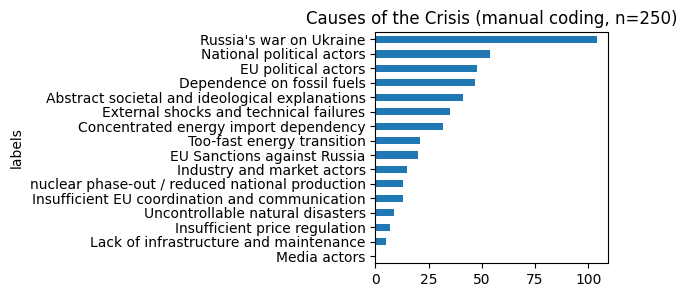

In [12]:
#Load Manual coding as gold standard

#Annotation=pd.read_excel("MANUAL CODING/2026-05-02 causes_manual_annotation MR filled.xlsx", sheet_name="Sheet1",header=0,index_col="labels").T
Annotation=pd.read_excel("MANUAL CODING/2026-05-13 causes_manual_annotation MR revised 2.xlsx",header=0,index_col="labels").T


Text=Annotation.iloc[1:,-4]

# remove the text, translation, and notes
Annotation = Annotation.drop(Annotation.columns[11:15], axis=1).fillna(0)

n_samples=Annotation.shape[0]

# plot the count in the manual annotation
s1 = Annotation.sum().sort_values()
s1.plot.barh(title=f"Causes of the Crisis (manual coding, n={n_samples})" , figsize=(3,3))
plt.tight_layout()
plt.show()
pd.set_option('display.max_colwidth', None)  # or a large number like 1000



In [14]:
# Get the mode (most common value from LLM code)
x_mode = x.groupby("orig_index").agg(lambda s: s.mode().iat[0])

# Combine LLM & manual coding to one dataframe
merged = pd.concat(
    [x_mode.set_axis(x_mode.index.astype(int)).add_prefix("ai_"),
     Annotation.set_axis(Annotation.index.astype(int)).add_prefix("manual_")],
    axis=1,
    join="inner"
)

codes=x_mode.columns

per_topic = MaxNLP.eval_ai_vs_manual(merged, question_list=codes).round(2)
print(f'average F1 ({x_runs} runs):', per_topic[per_topic["N-pos"]>5].F1.mean().round(2))
per_topic.sort_values("F1", ascending=False)

average F1 (4 runs): 0.7


,N,N-pos,TP,FP,TN,FN,Precision,Recall,F1,F-beta
Industry and market actors,250.0,15.0,13.0,1.0,234.0,2.0,0.93,0.87,0.90,0.99
Russia's war on Ukraine,250.0,104.0,86.0,4.0,142.0,18.0,0.96,0.83,0.89,0.91
National political actors,250.0,54.0,39.0,4.0,192.0,15.0,0.91,0.72,0.80,0.92
Uncontrollable natural disasters,250.0,9.0,6.0,0.0,241.0,3.0,1.00,0.67,0.80,0.99
Insufficient price regulation,250.0,7.0,5.0,1.0,242.0,2.0,0.83,0.71,0.77,0.99
nuclear phase-out / reduced national production,250.0,13.0,10.0,5.0,232.0,3.0,0.67,0.77,0.71,0.97
Abstract societal and ideological explanations,250.0,41.0,24.0,4.0,205.0,17.0,0.86,0.59,0.70,0.92
Concentrated energy import dependency,250.0,32.0,24.0,13.0,205.0,8.0,0.65,0.75,0.70,0.92
Too-fast energy transition,250.0,21.0,11.0,1.0,228.0,10.0,0.92,0.52,0.67,0.96
External shocks and technical failures,250.0,35.0,20.0,5.0,210.0,15.0,0.80,0.57,0.67,0.92


In [22]:
# Create Disagreement dataframes: total disagreement, FP & FN

disagree_df = pd.DataFrame({c: merged[f"ai_{c}"] != merged[f"manual_{c}"]  for c in codes}, index=merged.index)
fp_df = pd.DataFrame({c: (merged[f"ai_{c}"]==1) & (merged[f"manual_{c}"]==0)  for c in codes}, index=merged.index)
fn_df = pd.DataFrame({c: (merged[f"ai_{c}"]==0) & (merged[f"manual_{c}"]==1)  for c in codes}, index=merged.index)

In [24]:
# Create excel with colored disagreements.

#!pip install XlsxWriter             
MaxNLP.write_disagreement_excel(
    annotation_df=Annotation,
    merged_df=merged,
    codes=codes,
    path="2026-05-13 Disagreement manual code.xlsx"
)

,EU political actors,National political actors,Industry and market actors,Media actors,Russia's war on Ukraine,Too-fast energy transition,Dependence on fossil fuels,Concentrated energy import dependency,Uncontrollable natural disasters,External shocks and technical failures,Abstract societal and ideological explanations,Insufficient price regulation,EU Sanctions against Russia,nuclear phase-out / reduced national production
country,,,,,,,,,,,,,,
Belgium,0.08,0.04,0.00,0.0,0.12,0.00,0.24,0.04,0.04,0.12,0.12,0.00,0.08,0.04
Czech Republic,0.08,0.12,0.00,0.0,0.04,0.00,0.08,0.12,0.00,0.08,0.04,0.00,0.12,0.00
France,0.16,0.16,0.00,0.0,0.04,0.00,0.12,0.04,0.04,0.12,0.12,0.08,0.12,0.00
Germany,0.00,0.12,0.00,0.0,0.08,0.16,0.08,0.00,0.00,0.16,0.00,0.00,0.04,0.00
Italy,0.08,0.04,0.08,0.0,0.08,0.08,0.36,0.16,0.04,0.04,0.08,0.00,0.00,0.04
Netherlands,0.12,0.08,0.00,0.0,0.28,0.04,0.24,0.24,0.00,0.12,0.04,0.04,0.04,0.08
Poland,0.20,0.00,0.00,0.0,0.08,0.08,0.20,0.12,0.00,0.08,0.16,0.00,0.00,0.12
Portugal,0.04,0.08,0.04,0.0,0.08,0.00,0.08,0.04,0.00,0.04,0.04,0.00,0.00,0.00
Romania,0.04,0.00,0.00,0.0,0.04,0.04,0.04,0.00,0.00,0.04,0.20,0.00,0.04,0.04


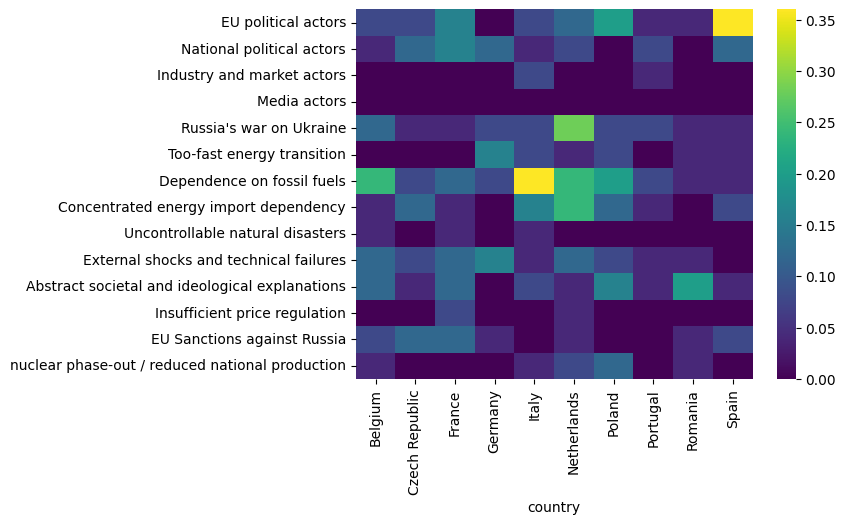

In [25]:
# Visualize disagreements

import seaborn as sns
cols = [c.replace('manual_','') for c in merged.columns if c.startswith('manual_') and f'ai_{c.replace("manual_","")}' in merged.columns]
disagree = merged[[f'ai_{c}' for c in cols]].astype(int).ne(merged[[f'manual_{c}' for c in cols]].astype(int).set_axis([f'ai_{c}' for c in cols], axis=1)).set_axis(cols, axis=1)
df_country = (df_t[['country']].join(disagree).groupby('country', dropna=False).mean().round(2).astype(float))
sns.heatmap(df_country.T, cmap='viridis'); 

df_country

<Axes: >

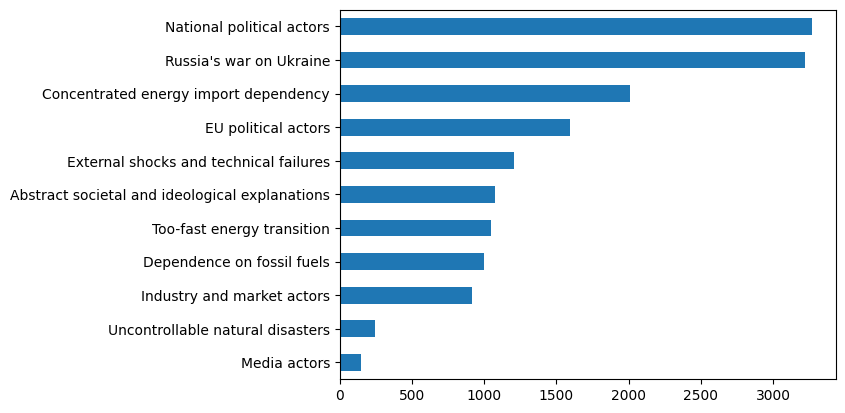

In [29]:
x.sum().sort_values().plot.barh()

    meaning=texts["QID5"]
    causes=texts["QID8"]
    response=texts["QID10"]
    consequence=texts["QID15"]
    moral=texts["QID19"]